In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [121]:
loyalty  = pd.read_csv("Customer Loyalty History (1).csv")
flights  = pd.read_csv("Customer Flight Activity (1).csv")
calendar = pd.read_csv("Calendar (1).csv")

In [122]:
def subsection(title):
    print(f"\n--- {title} ---")

In [123]:
def section(title):
    print("\n" + "=" * 60)
    print(f"  {title}")
    print("=" * 60)

In [124]:
loyalty.head(5)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [125]:
flights.head(5)

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


# Schema Overview

In [126]:
for label, df in [("LOYALTY HISTORY", loyalty), ("FLIGHT ACTIVITY", flights)]:
    subsection(label)
    subsection(df.shape)
    info = pd.DataFrame({
        "total":    df.count(),
        "dtype":    df.dtypes.astype(str),
        "nulls":    df.isnull().sum(),
        "null_%":   (df.isnull().mean() * 100).round(2),
        "unique":   df.nunique(),
        "sample":   df.iloc[0]
    })
    print(info.to_string())


--- LOYALTY HISTORY ---

--- (16737, 16) ---
                    total    dtype  nulls  null_%  unique    sample
Loyalty Number      16737    int64      0    0.00   16737    480934
Country             16737   object      0    0.00       1    Canada
Province            16737   object      0    0.00      11   Ontario
City                16737   object      0    0.00      29   Toronto
Postal Code         16737   object      0    0.00      55   M2Z 4K1
Gender              16737   object      0    0.00       2    Female
Education           16737   object      0    0.00       5  Bachelor
Salary              12499  float64   4238   25.32    5890   83236.0
Marital Status      16737   object      0    0.00       3   Married
Loyalty Card        16737   object      0    0.00       3      Star
CLV                 16737  float64      0    0.00    7984   3839.14
Enrollment Type     16737   object      0    0.00       2  Standard
Enrollment Year     16737    int64      0    0.00       7      2016
En

## Findings

* 25% null values in salary column.
* 87.65% null values in cancellation year and cancellation month columns.

In [127]:
calendar.head(5)

,Date,Start of Year,Start of Quarter,Start of Month
0,2012-01-01,2012-01-01,2012-01-01,2012-01-01
1,2012-01-02,2012-01-01,2012-01-01,2012-01-01
2,2012-01-03,2012-01-01,2012-01-01,2012-01-01
3,2012-01-04,2012-01-01,2012-01-01,2012-01-01
4,2012-01-05,2012-01-01,2012-01-01,2012-01-01


# Loyalty History Deep Dive

In [128]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [129]:
loyalty.describe()

,Loyalty Number,Salary,CLV,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
count,16737.000000,12499.000000,16737.000000,16737.000000,16737.000000,2067.000000,2067.000000
mean,549735.880445,79245.609409,7988.896536,2015.253211,6.669116,2016.503145,6.962748
std,258912.132453,35008.297285,6860.982280,1.979111,3.398958,1.380743,3.455297
min,100018.000000,-58486.000000,1898.010000,2012.000000,1.000000,2013.000000,1.000000
25%,326603.000000,59246.500000,3980.840000,2014.000000,4.000000,2016.000000,4.000000
50%,550434.000000,73455.000000,5780.180000,2015.000000,7.000000,2017.000000,7.000000
75%,772019.000000,88517.500000,8940.580000,2017.000000,10.000000,2018.000000,10.000000
max,999986.000000,407228.000000,83325.380000,2018.000000,12.000000,2018.000000,12.000000


### Finding

Negative values in salary column.

## Cancellation Status

In [133]:
subsection("Cancellation status")
cancelled = loyalty["Cancellation Year"].notna().sum()
total     = len(loyalty)
print(f"  Cancelled members  : {cancelled:,} ({cancelled/total*100:.1f}%)")
print(f"  Active members     : {total - cancelled:,} ({(total-cancelled)/total*100:.1f}%)")


--- Cancellation status ---
  Cancelled members  : 2,067 (12.3%)
  Active members     : 14,670 (87.7%)


### Finding

Only 12.3% formally cancelled. That means 87.7% never officially left, but that doesn't mean they're all actively flying. So if will build our churn model only on 12.3% of data, then we are ignoring the silent inactive users which have yet not cancelled

## Cancellation Year Wise

In [111]:
print("\n  Cancellations by year:")
yr_counts = loyalty["Cancellation Year"].value_counts().sort_index()
for yr, cnt in yr_counts.items():
    bar = "█" * int(cnt / yr_counts.max() * 50) # calculation to just reduce the no. of bars
    print(f"    {int(yr)}  {bar}  {cnt:,}")


  Cancellations by year:
    2013  ███  43
    2014  ██████████████  181
    2015  ████████████████████  265
    2016  █████████████████████████████████  427
    2017  ███████████████████████████████████████  506
    2018  ██████████████████████████████████████████████████  645


### Finding

No. of cancellation has been on a rise with years.

## Tier Count

In [112]:
print(loyalty["Loyalty Card"].value_counts().sort_index())

Loyalty Card
Aurora    3429
Nova      5671
Star      7637
Name: count, dtype: int64


### Finding

Follow a pyraimd shape. Most members are at the botton tier, fewer at the top.

## Enrollment Type

In [138]:
total = len(loyalty)
print(loyalty["Enrollment Type"].value_counts().sort_index())

Enrollment Type
2018 Promotion      971
Standard          15766
Name: count, dtype: int64


### Finding

5.8% of loyalty user came from the 2018 promotion drive.

## Demographic Check


--- Education & marital status (demographic check) ---
  
Education
Bachelor                10475
College                  4238
High School or Below      782
Doctor                    734
Master                    508
Total   16737


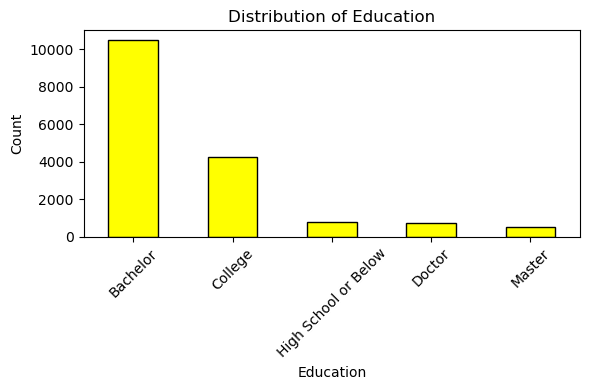

  
Marital Status
Married     9735
Single      4484
Divorced    2518
Total   16737


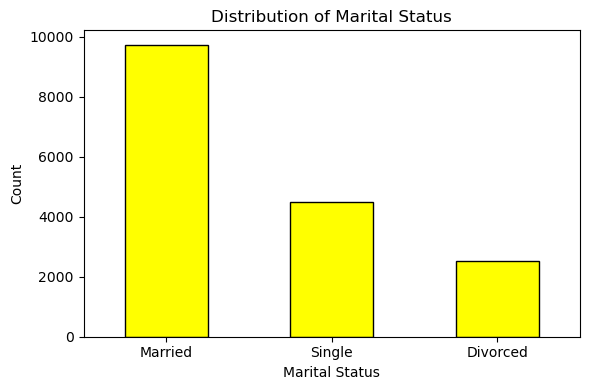

  
Gender
Female    8410
Male      8327
Total   16737


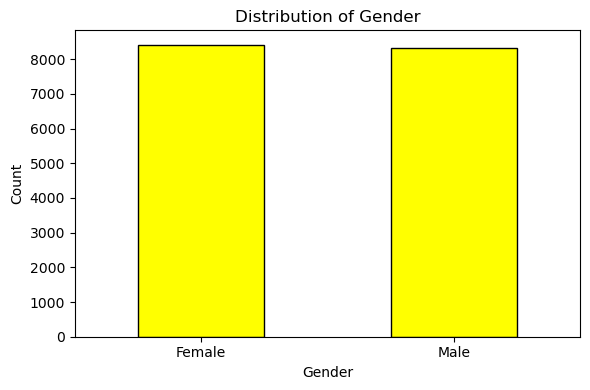

  
Province
Ontario                 5404
British Columbia        4409
Quebec                  3300
Alberta                  969
Manitoba                 658
New Brunswick            636
Nova Scotia              518
Saskatchewan             409
Newfoundland             258
Yukon                    110
Prince Edward Island      66
Total   16737


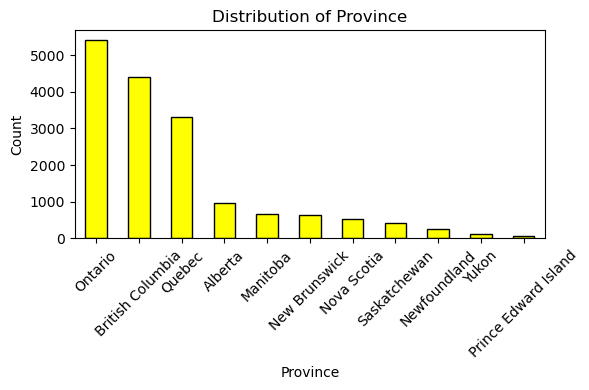

  
City
Toronto           3351
Vancouver         2582
Montreal          2059
Winnipeg           658
Whistler           582
Halifax            518
Ottawa             509
Trenton            486
Edmonton           486
Quebec City        485
Dawson Creek       444
Fredericton        425
Regina             409
Kingston           401
Tremblant          398
Victoria           389
Hull               358
West Vancouver     324
St. John's         258
Thunder Bay        256
Sudbury            227
Moncton            211
Calgary            191
Banff              179
London             174
Peace River        113
Whitehorse         110
Kelowna             88
Charlottetown       66
Total   16737


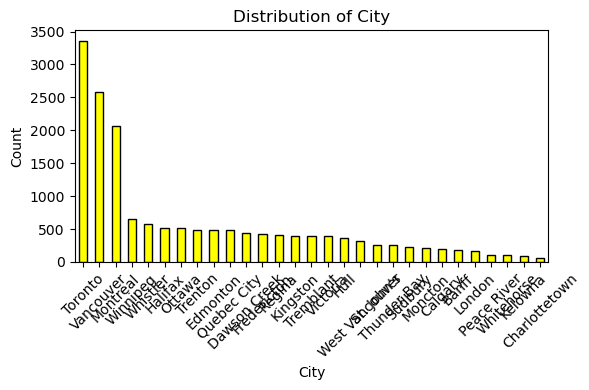

In [141]:
subsection("Education & marital status (demographic check)")
total = len(loyalty)
for col in ["Education", "Marital Status", "Gender", "Province", "City"]:
    vc = loyalty[col].value_counts()
    print("  ")
    print(vc.to_string())
    print(f"Total   {vc.sum()}")

    plt.figure(figsize=(6, 4))
    vc.plot(kind="bar", color="Yellow", edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.xticks(rotation=45 if col == "Province" or col == "Education" or col == "City" else 0) # Rotate only if needed
    plt.tight_layout()
    plt.show()

### Findings

* 62.6% are Bachelor degree holders. College students make up 25.3% that's a significant chunk.
* Majority married. Marital status may correlate with travel pattern as they travel for family holidays, single for free time or business.
* Gender is perfectly balanced this implies it might not be a strong segmentation feature.
* Three provinces dominate: Ontario, BC, and Quebec together account for 78.3% of all members.

## Cleaning

### Treating Null values in Salary column

In [115]:
unique_education_null_salary = loyalty.loc[loyalty['Salary'].isna(), 'Education'].unique()
print(unique_education_null_salary)

['College']


 Therefore, the null values in the salary column are those for students.

In [116]:
# replacing NAN values with zero
loyalty['Salary'] = loyalty['Salary'].fillna(0)

In [117]:
loyalty['Salary'].head()

0     83236.0
1         0.0
2         0.0
3         0.0
4    103495.0
Name: Salary, dtype: float64

### Treating Negative values in Salary column

In [118]:
loyalty[loyalty["Salary"] < 0]

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
1082,542976,Canada,Quebec,Montreal,H2Y 4R4,Male,High School or Below,-49830.0,Divorced,Star,24127.50,2018 Promotion,2018,3,NaN,NaN
1894,959977,Canada,British Columbia,Vancouver,V5R 1W3,Female,Bachelor,-12497.0,Married,Aurora,9453.00,2018 Promotion,2018,3,NaN,NaN
2471,232755,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,NaN,NaN
3575,525245,Canada,British Columbia,Victoria,V10 6T5,Male,Bachelor,-45962.0,Married,Star,2402.33,2018 Promotion,2018,3,NaN,NaN
3932,603070,Canada,British Columbia,West Vancouver,V6V 8Z3,Female,Bachelor,-19325.0,Single,Star,2893.74,2018 Promotion,2018,3,NaN,NaN
4712,491242,Canada,British Columbia,Dawson Creek,U5I 4F1,Male,Bachelor,-43234.0,Married,Star,7597.91,2018 Promotion,2018,3,NaN,NaN
6560,115505,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,NaN,NaN
6570,430398,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,NaN,NaN
7373,152016,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,NaN,NaN
8576,194065,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,NaN,NaN


### Findings

* There are 20 negative values in Salary column.
* 19 of then are for Bachelors and 1 for High School or below.

In [74]:
# Replace negative with NaN first
loyalty.loc[loyalty['Salary'] < 0, 'Salary'] = None

# Then impute with median of their own education group
education_medians = loyalty.groupby('Education')['Salary'].median()
loyalty['Salary'] = loyalty['Salary'].fillna(loyalty['Education'].map(education_medians))

In [75]:
# checking are there till some negative values
print(loyalty['Salary'].lt(0).sum())

0


# Flight Activity Deep Dive

In [76]:
flights.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


In [77]:
flights.describe()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
count,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000,392936.000000
mean,550527.519034,2017.513661,6.513661,1.294888,1941.440201,2027.172345,31.304263,5.635661
std,258604.580187,0.499814,3.445428,1.962675,3239.975889,3872.139841,126.653775,22.801167
min,100018.000000,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,327688.000000,2017.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,551833.000000,2018.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,772194.000000,2018.000000,10.000000,2.000000,3018.000000,3039.000000,0.000000,0.000000
max,999986.000000,2018.000000,12.000000,28.000000,67284.000000,100926.000000,876.000000,158.000000


## Zero Activity Months

In [78]:
subsection("Zero-activity check (months with no flights)")
zero_months = (flights["Total Flights"] == 0).sum()
total_rows  = len(flights)
print(f"  Months with 0 flights booked: {zero_months:,} ({zero_months/total_rows*100:.1f}% of all monthly records)")


--- Zero-activity check (months with no flights) ---
  Months with 0 flights booked: 214,122 (54.5% of all monthly records)


### Finding

More than half of all monthly records show zero flights. That means in any given month, the majority of loyalty members are not flying at all.

# Total Flight by Month

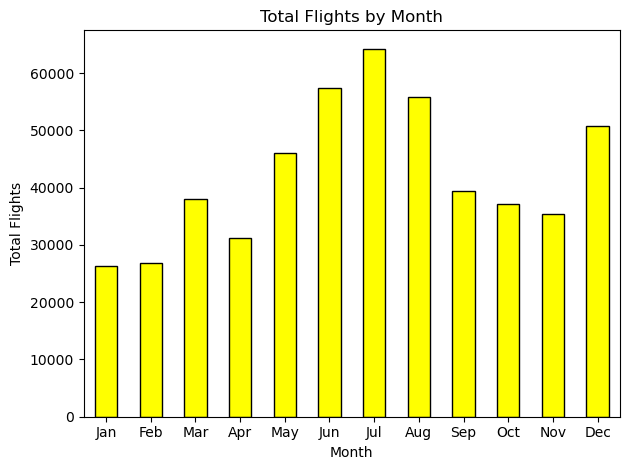

In [79]:
# List of month names
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Group, plot, and replace numbers with names
ax = flights.groupby('Month')['Total Flights'].sum().plot(kind='bar', color='yellow', edgecolor='black')
ax.set_xticklabels(months, rotation=0)

# Labels and save
plt.title('Total Flights by Month')
plt.ylabel('Total Flights')
plt.xlabel('Month')
plt.tight_layout()

### Finding

Flights books are high at the time of vaccation as proven by above graph.

In [80]:
subsection("Anomaly check — negative values")
numeric_cols = flights.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    neg_count = (flights[col] < 0).sum()
    if neg_count > 0:
        print(f"  ⚠  {col}: {neg_count} negative values — flag for cleaning")


--- Anomaly check — negative values ---


No anomaly detected.

In [81]:
section("STEP 6 — Join integrity check")

loyalty_ids = set(loyalty["Loyalty Number"].unique())
flight_ids  = set(flights["Loyalty Number"].unique())
 
in_both      = loyalty_ids & flight_ids
only_loyalty = loyalty_ids - flight_ids
only_flight  = flight_ids  - loyalty_ids
 
print(f"\n  Loyalty ID column  : '{loyalty_id_col}'")
print(f"  Flight ID column   : '{flight_id_col}'")
print(f"\n  Members in both files        : {len(in_both):,}")
print(f"  In loyalty only (no activity): {len(only_loyalty):,}  ← likely inactive / churned")
print(f"  In flight only (no profile)  : {len(only_flight):,}  ← data quality issue if > 0")


  STEP 6 — Join integrity check

  Loyalty ID column  : 'Loyalty Number'
  Flight ID column   : 'Loyalty Number'

  Members in both files        : 16,737
  In loyalty only (no activity): 0  ← likely inactive / churned
  In flight only (no profile)  : 0  ← data quality issue if > 0


* For each loyalty number we have the entire data.
* There is no flight record with no matching loyalty profile.

# Plots

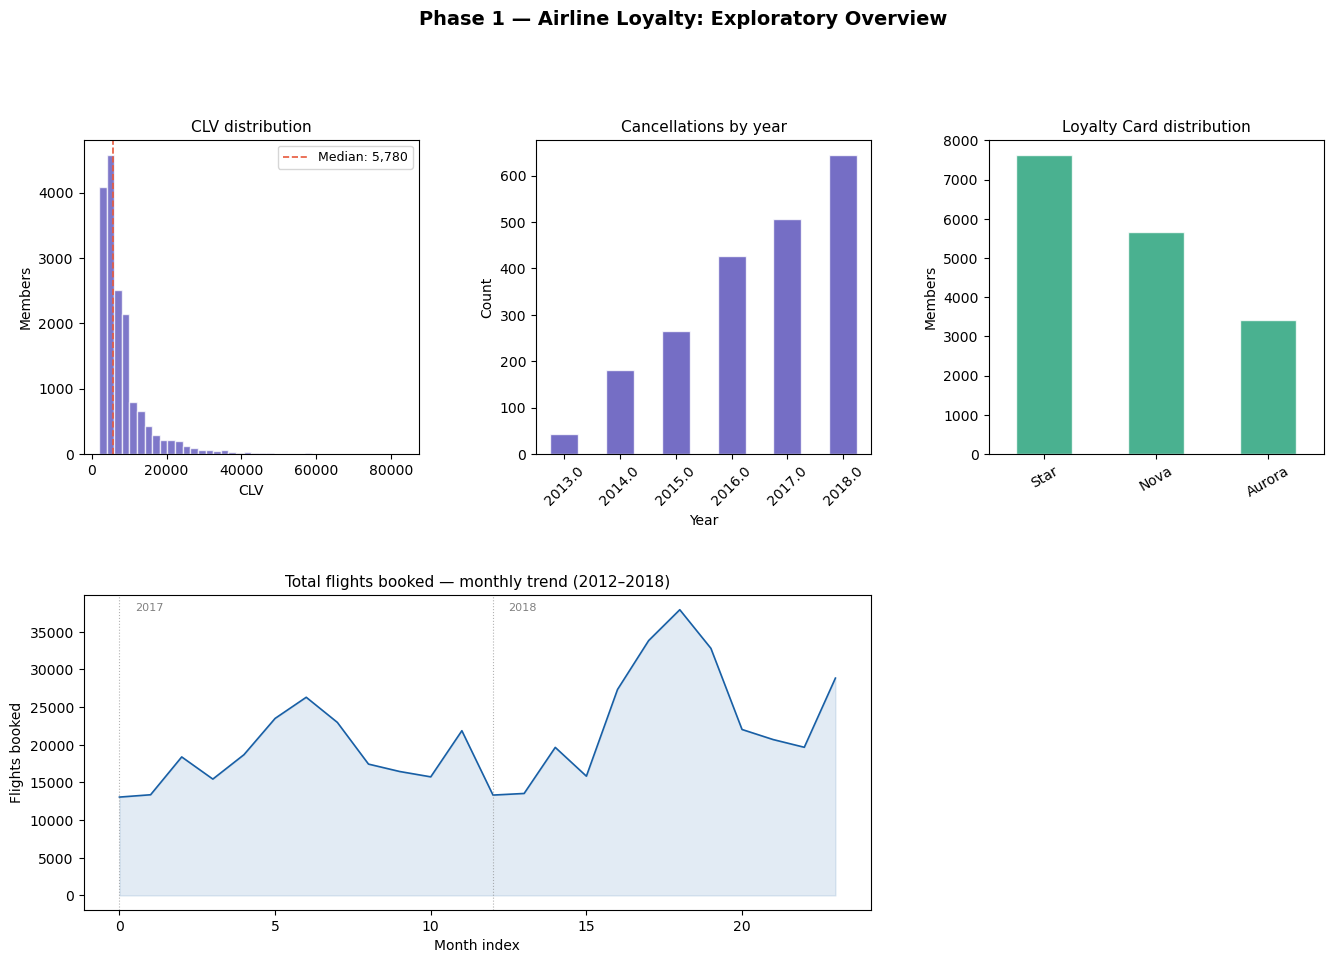

In [82]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Phase 1 — Airline Loyalty: Exploratory Overview", fontsize=14, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

clv_col = "CLV"

# Plot 1 — CLV distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(clv_clean, bins=40, color="#534AB7", alpha=0.75, edgecolor="white")
ax1.set_title("CLV distribution", fontsize=11)
ax1.set_xlabel("CLV")
ax1.set_ylabel("Members")
ax1.axvline(clv_clean.median(), color="#E8593C", linestyle="--", linewidth=1.2, label=f"Median: {clv_clean.median():,.0f}")
ax1.legend(fontsize=9)

# Plot 2 — Cancellations by year
ax2 = fig.add_subplot(gs[0, 1])
yr_counts.plot(kind="bar", ax=ax2, color="#534AB7", alpha=0.8, edgecolor="white")
ax2.set_title("Cancellations by year", fontsize=11)
ax2.set_xlabel("Year")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=45)

tier_col = "Loyalty Card"

# Plot 3 — Loyalty tier distribution
ax3 = fig.add_subplot(gs[0, 2])
loyalty[tier_col].value_counts().plot(kind="bar", ax=ax3, color="#1D9E75", alpha=0.8, edgecolor="white")
ax3.set_title(f"{tier_col} distribution", fontsize=11)
ax3.set_xlabel("")
ax3.set_ylabel("Members")
ax3.tick_params(axis="x", rotation=30)

yr_col = "Year"
mo_col = "Month"
flights_booked_col = "Total Flights"

# Plot 4 — Monthly flights over time
ax4 = fig.add_subplot(gs[1, :2])
monthly = flights.groupby([yr_col, mo_col])[flights_booked_col].sum().reset_index()
monthly["period"] = monthly[yr_col].astype(str) + "-" + monthly[mo_col].astype(str).str.zfill(2)
monthly = monthly.sort_values("period")
ax4.plot(range(len(monthly)), monthly[flights_booked_col], color="#185FA5", linewidth=1.2)
ax4.set_title("Total flights booked — monthly trend (2012–2018)", fontsize=11)
ax4.set_xlabel("Month index")
ax4.set_ylabel("Flights booked")
ax4.fill_between(range(len(monthly)), monthly[flights_booked_col], alpha=0.12, color="#185FA5")
# Mark years
year_starts = monthly.groupby(yr_col).head(1).reset_index()
for _, row in year_starts.iterrows():
    idx = monthly[monthly[yr_col] == row[yr_col]].index[0]
    pos = list(monthly.index).index(idx)
    ax4.axvline(pos, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
    ax4.text(pos + 0.5, ax4.get_ylim()[1] * 0.95, str(int(row[yr_col])), fontsize=8, color="gray")

In [86]:
calendar.head(10)

,Date,Start of Year,Start of Quarter,Start of Month
0,2012-01-01,2012-01-01,2012-01-01,2012-01-01
1,2012-01-02,2012-01-01,2012-01-01,2012-01-01
2,2012-01-03,2012-01-01,2012-01-01,2012-01-01
3,2012-01-04,2012-01-01,2012-01-01,2012-01-01
4,2012-01-05,2012-01-01,2012-01-01,2012-01-01
5,2012-01-06,2012-01-01,2012-01-01,2012-01-01
6,2012-01-07,2012-01-01,2012-01-01,2012-01-01
7,2012-01-08,2012-01-01,2012-01-01,2012-01-01
8,2012-01-09,2012-01-01,2012-01-01,2012-01-01
9,2012-01-10,2012-01-01,2012-01-01,2012-01-01


In [87]:
calendar.shape

(2557, 4)

In [84]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2557 entries, 0 to 2556
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              2557 non-null   object
 1   Start of Year     2557 non-null   object
 2   Start of Quarter  2557 non-null   object
 3   Start of Month    2557 non-null   object
dtypes: object(4)
memory usage: 80.0+ KB


In [88]:
# ─────────────────────────────────────────
# STEP 9 — MERGE PREVIEW
# ─────────────────────────────────────────
section("STEP 9 — Merge preview (loyalty + flights)")
 
merged = flights.merge(loyalty, on="Loyalty Number", how="inner")
print(f"  Merged shape: {merged.shape[0]:,} rows × {merged.shape[1]} columns")
print(f"  (Each row = one member's activity in one month)")


  STEP 9 — Merge preview (loyalty + flights)
  Merged shape: 392,936 rows × 23 columns
  (Each row = one member's activity in one month)
